In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#upload orders_300k_dirty.csv
from google.colab import files

uploaded = files.upload()

Saving orders_300k_dirty.csv to orders_300k_dirty.csv


In [7]:
df = pd.read_csv("orders_300k_dirty.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
##understand the data
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 300000
Number of columns: 8


In [9]:
df.head()

,order_id,customer_id,product_id,order_amount,order_date,payment_method,status,quantity
0,06b5aa88-f86f-4e07-8e4b-6df36402c209,0a331d4c-a73d-4271-83ac-2f6726635495,PROD-0060,473.82,2025-07-29,wall-et,success,1
1,5b10b856-e084-471c-bc16-8dbab95e3f33,9e48263f-7923-4cb9-8138-b9da8eb85619,PROD-0393,17796.32,2024/31/01,card,success,1
2,88706122-160e-4721-b537-73cee232fcd5,245fac1f-5ac1-4448-acc9-70ff980a4e9b,PROD-0332,31201.75,2024-03-02,wallet,success,2
3,c6ae75af-0313-4194-a788-8802515af2e4,abfda25e-6a38-4aa8-be24-cd22f371b2b0,PROD-0059,42282.89,NaN,wallet,refunded,2
4,032ab1c7-8882-47d8-a2ac-fbefc1cfb2eb,e0010492-b072-4f48-abd6-8a87938fad24,PROD-0342,27100.3,2024-02-11,wallet,success,1


In [10]:
print(df.columns.tolist())

['order_id', 'customer_id', 'product_id', 'order_amount', 'order_date', 'payment_method', 'status', 'quantity']


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        300000 non-null  object
 1   customer_id     300000 non-null  object
 2   product_id      300000 non-null  object
 3   order_amount    287170 non-null  object
 4   order_date      282086 non-null  object
 5   payment_method  300000 non-null  object
 6   status          300000 non-null  object
 7   quantity        300000 non-null  object
dtypes: object(8)
memory usage: 18.3+ MB


In [12]:
#Check missing values and missing percentage
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing

,Missing Values,Missing Percentage
order_id,0,0.00
customer_id,0,0.00
product_id,0,0.00
order_amount,12830,4.28
order_date,17914,5.97
payment_method,0,0.00
status,0,0.00
quantity,0,0.00


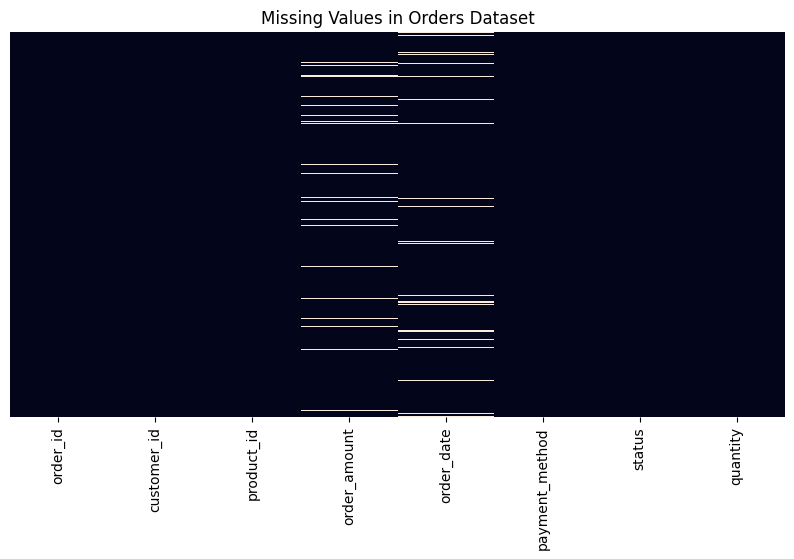

In [13]:
#visualize the missing values
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Orders Dataset")
plt.show()

In [14]:
#Duplicate
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (300000, 8)


In [16]:
print(
    "Duplicate order IDs:",
    df["order_id"].duplicated().sum()
)

Duplicate order IDs: 0


In [17]:
#Clean column name
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['order_id', 'customer_id', 'product_id', 'order_amount', 'order_date', 'payment_method', 'status', 'quantity']


In [18]:
#identify numeric column
df.select_dtypes(include="number").columns

Index([], dtype='object')

In [19]:
#convert numeric column
if "order_amount" in df.columns:
    df["order_amount"] = pd.to_numeric(
        df["order_amount"],
        errors="coerce"
    )

if "quantity" in df.columns:
    df["quantity"] = pd.to_numeric(
        df["quantity"],
        errors="coerce"
    )

In [20]:
#clean text column
df.select_dtypes(include="object").columns

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'payment_method',
       'status'],
      dtype='object')

In [21]:
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
    )

In [22]:
#standardize text to lower case
categorical_columns = [
    col for col in [
        "payment_method",
        "status",
        "order_status",
        "product_category"
    ]
    if col in df.columns
]

for col in categorical_columns:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

In [23]:
#convert date column
if "order_date" in df.columns:
    df["order_date"] = pd.to_datetime(
        df["order_date"],
        errors="coerce"
    )

In [24]:
#check invalid date
if "order_date" in df.columns:
    print(
        "Missing/invalid order dates:",
        df["order_date"].isna().sum()
    )

Missing/invalid order dates: 90000


In [25]:
df.isnull().sum()

,0
order_id,0
customer_id,0
product_id,0
order_amount,25727
order_date,90000
payment_method,0
status,0
quantity,30147


In [38]:
#handle missing values for numeric column
numeric_columns = df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(
            df[col].median()
        )

In [39]:
#for categorical column
categorical_columns = df.select_dtypes(
    include=["object", "string"]
).columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna("unknown")

In [40]:
#create calculated field
if "order_amount" in df.columns:
    df["order_value_category"] = pd.qcut(
        df["order_amount"],
        q=4,
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High"
        ],
        duplicates="drop"
    )

In [41]:
#create date based field
if "order_date" in df.columns:

    df["order_year"] = df["order_date"].dt.year

    df["order_month"] = df["order_date"].dt.month

    df["order_month_name"] = (
        df["order_date"].dt.month_name()
    )

    df["order_day"] = df["order_date"].dt.day

In [42]:
#categorize order amount
if "order_amount" in df.columns:

    df["order_value_category"] = pd.qcut(
        df["order_amount"],
        q=4,
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High"
        ],
        duplicates="drop"
    )

df.head()

,order_id,customer_id,product_id,order_amount,order_date,payment_method,status,quantity,order_value_category,order_year,order_month,order_month_name,order_day
0,06b5aa88-f86f-4e07-8e4b-6df36402c209,0a331d4c-a73d-4271-83ac-2f6726635495,PROD-0060,473.82,2025-07-29,wall-et,success,1.0,Low,2025.0,7.0,July,29.0
1,5b10b856-e084-471c-bc16-8dbab95e3f33,9e48263f-7923-4cb9-8138-b9da8eb85619,PROD-0393,17796.32,NaT,card,success,1.0,Medium,NaN,NaN,NaN,NaN
2,88706122-160e-4721-b537-73cee232fcd5,245fac1f-5ac1-4448-acc9-70ff980a4e9b,PROD-0332,31201.75,2024-03-02,wallet,success,2.0,High,2024.0,3.0,March,2.0
3,c6ae75af-0313-4194-a788-8802515af2e4,abfda25e-6a38-4aa8-be24-cd22f371b2b0,PROD-0059,42282.89,NaT,wallet,refunded,2.0,Very High,NaN,NaN,NaN,NaN
4,032ab1c7-8882-47d8-a2ac-fbefc1cfb2eb,e0010492-b072-4f48-abd6-8a87938fad24,PROD-0342,27100.30,2024-02-11,wallet,success,1.0,High,2024.0,2.0,February,11.0


In [43]:
#outlier detection
if "order_amount" in df.columns:

    Q1 = df["order_amount"].quantile(0.25)
    Q3 = df["order_amount"].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)

Lower bound: -28977.692499999997
Upper bound: 76405.8675


In [44]:
#identify outliers
if "order_amount" in df.columns:

    outliers = df[
        (df["order_amount"] < lower_bound) |
        (df["order_amount"] > upper_bound)
    ]

    print(
        "Number of potential outliers:",
        len(outliers)
    )

Number of potential outliers: 12883


"Potential outliers were identified using the IQR method. They were retained because unusually large orders may represent genuine transactions."

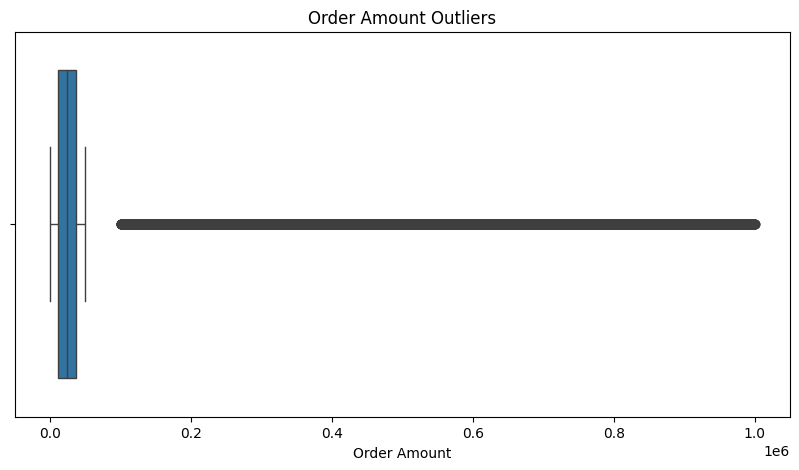

In [45]:
#visualize order amount
if "order_amount" in df.columns:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df["order_amount"]
    )

    plt.title("Order Amount Outliers")
    plt.xlabel("Order Amount")

    plt.show()

In [46]:
#order amount summary
if "order_amount" in df.columns:

    print(df["order_amount"].describe())

count    300000.000000
mean      45455.177706
std      120984.589008
min         -50.000000
25%       10541.142500
50%       23711.300000
75%       36887.032500
max      999969.870000
Name: order_amount, dtype: float64


In [47]:
#order by customer
if "customer_id" in df.columns:

    customer_summary = (
        df.groupby("customer_id")
        .agg(
            total_orders=("order_id", "nunique"),
            total_spend=("order_amount", "sum"),
            average_order_value=("order_amount", "mean")
        )
        .reset_index()
    )

    customer_summary.head()

In [48]:
#Final Date quality check
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Final dataset shape: (300000, 13)

Missing values:
order_id                    0
customer_id                 0
product_id                  0
order_amount                0
order_date              90000
payment_method              0
status                      0
quantity                    0
order_value_category        0
order_year              90000
order_month             90000
order_month_name        90000
order_day               90000
dtype: int64

Duplicate rows:
0


In [49]:
df.head(10)

,order_id,customer_id,product_id,order_amount,order_date,payment_method,status,quantity,order_value_category,order_year,order_month,order_month_name,order_day
0,06b5aa88-f86f-4e07-8e4b-6df36402c209,0a331d4c-a73d-4271-83ac-2f6726635495,PROD-0060,473.82,2025-07-29,wall-et,success,1.0,Low,2025.0,7.0,July,29.0
1,5b10b856-e084-471c-bc16-8dbab95e3f33,9e48263f-7923-4cb9-8138-b9da8eb85619,PROD-0393,17796.32,NaT,card,success,1.0,Medium,NaN,NaN,NaN,NaN
2,88706122-160e-4721-b537-73cee232fcd5,245fac1f-5ac1-4448-acc9-70ff980a4e9b,PROD-0332,31201.75,2024-03-02,wallet,success,2.0,High,2024.0,3.0,March,2.0
3,c6ae75af-0313-4194-a788-8802515af2e4,abfda25e-6a38-4aa8-be24-cd22f371b2b0,PROD-0059,42282.89,NaT,wallet,refunded,2.0,Very High,NaN,NaN,NaN,NaN
4,032ab1c7-8882-47d8-a2ac-fbefc1cfb2eb,e0010492-b072-4f48-abd6-8a87938fad24,PROD-0342,27100.30,2024-02-11,wallet,success,1.0,High,2024.0,2.0,February,11.0
5,0f2433b5-1f67-4446-9849-edff493026c2,bdf18b4d-db9f-46f0-8758-44a938529a49,PROD-0297,2393.67,2025-11-09,card,success,4.0,Low,2025.0,11.0,November,9.0
6,71223631-9926-4ced-b994-60a6d97d1001,5380805b-1e8f-434c-a898-bfe678c2ea7a,PROD-0137,12532.69,2025-12-01,upi,success,5.0,Medium,2025.0,12.0,December,1.0
7,4acbdb89-3acd-40ff-ab86-87af982fcca8,a4bc8fc9-f452-43b3-a4c1-eaf7cec182ae,PROD-0010,47079.63,2025-08-20,card,success,2.0,Very High,2025.0,8.0,August,20.0
8,cc6dcafa-a53f-4be5-aee3-ec29d5994f0d,d7e5abd4-33ab-404f-adc1-de28fb6756ae,PROD-0243,32901.99,2025-02-27,upi,failed,5.0,High,2025.0,2.0,February,27.0
9,184ee64a-b795-4137-868f-9a90c6580ba2,b6a71ba1-8f4b-4f82-a131-c987879c104d,PROD-0084,3858.55,2023-12-30,upi,success,3.0,Low,2023.0,12.0,December,30.0


In [51]:
#export processed dataset
processed_file = "Processed Data.csv"

df.to_csv(
    processed_file,
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
